# Installing the Necessary Libraries


In [33]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Loading the Data

In [34]:
df = pd.read_csv("/content/drive/MyDrive/Bengaluru_House_Data.csv")

In [35]:
print("First 5 rows of the DataFrame:")
display(df.head())

First 5 rows of the DataFrame:


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [36]:
print("DataFrame information (data types, non-null counts):")
display(df.info())

DataFrame information (data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


None

In [37]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [38]:
print("Shape of the DataFrame (rows, columns):")
print(df.shape)

Shape of the DataFrame (rows, columns):
(13320, 9)


In [39]:
print("Number of unique values per column:")
display(df.nunique())

Number of unique values per column:


,0
area_type,4
availability,81
location,1305
size,31
society,2688
total_sqft,2117
bath,19
balcony,4
price,1994


# DATA CLEANING

In [61]:
area_type_mapping = {
    'Plot Area': 0,
    'Built-up Area': 1,
    'Super built-up Area': 2
}
df['area_type'] = df['area_type'].str.strip().str.replace('\s+', ' ', regex=True)
df['area_type_encoded'] = df['area_type'].map(area_type_mapping)
print("DataFrame after encoding 'area_type':")
display(df[['area_type', 'area_type_encoded']].head())

DataFrame after encoding 'area_type':


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1429646363.py:6: SyntaxWarning: invalid escape sequence '\s'
  df['area_type'] = df['area_type'].str.strip().str.replace('\s+', ' ', regex=True)


,area_type,area_type_encoded
0,Super built-up Area,2.0
1,Plot Area,0.0
2,Built-up Area,1.0
3,Super built-up Area,2.0
4,Super built-up Area,2.0


In [41]:
df['availability_encoded'] = df['availability'].apply(lambda x: 0 if x == 'Ready To Move' else 1)
print("DataFrame after encoding 'availability':")
display(df[['availability', 'availability_encoded']].head())

DataFrame after encoding 'availability':


,availability,availability_encoded
0,19-Dec,1
1,Ready To Move,0
2,Ready To Move,0
3,Ready To Move,0
4,Ready To Move,0


In [42]:
df['size'] = df['size'].str.replace(' BHK', '', regex=False).str.replace(' Bedroom', '', regex=False).str.strip()
print("DataFrame after removing ' BHK' and ' Bedroom' from 'size' column:")
display(df[['size']].head())

DataFrame after removing ' BHK' and ' Bedroom' from 'size' column:


,size
0,2
1,4
2,3
3,3
4,2


In [44]:
print("Unique values in 'total_sqft' before cleaning (first 20):")
display(df['total_sqft'].value_counts().head(20))

Unique values in 'total_sqft' before cleaning (first 20):


,count
total_sqft,
1200,843
1100,221
1500,205
2400,196
600,180
1000,172
1350,133
1050,123
1300,117


In [47]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,area_type_encoded,availability_encoded,total_sqft_numeric,total_sqft_category
0,Super built-up Area,19-Dec,Electronic City Phase II,2,Coomee,1056,2.0,1.0,39.07,2.0,1,1056.0,1.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4,Theanmp,2600,5.0,3.0,120.00,0.0,0,2600.0,3.0
2,Built-up Area,Ready To Move,Uttarahalli,3,NaN,1440,2.0,3.0,62.00,1.0,0,1440.0,1.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3,Soiewre,1521,3.0,1.0,95.00,2.0,0,1521.0,2.0
4,Super built-up Area,Ready To Move,Kothanur,2,NaN,1200,2.0,1.0,51.00,2.0,0,1200.0,1.0


# EXPLORATORY DATA ANALYSIS

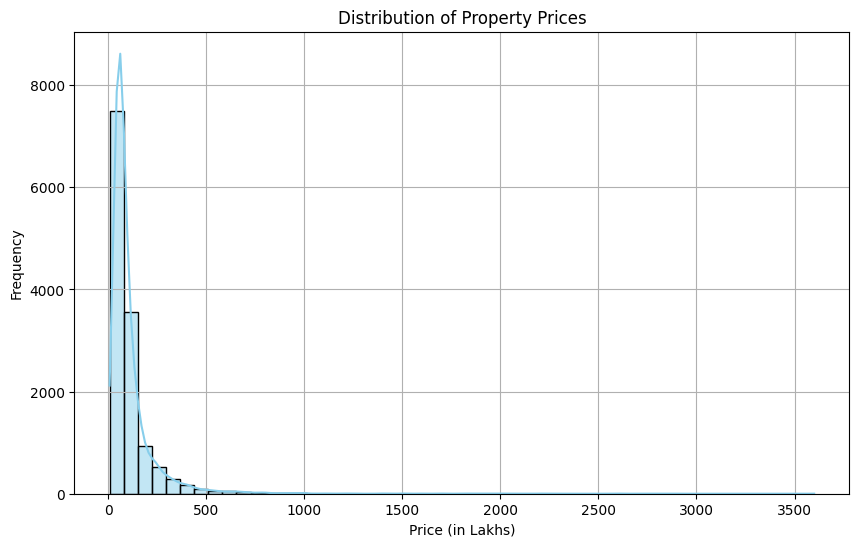

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Property Prices')
plt.xlabel('Price (in Lakhs)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

/tmp/ipython-input-1798476550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='area_type_encoded', y='price', data=df, palette='viridis')


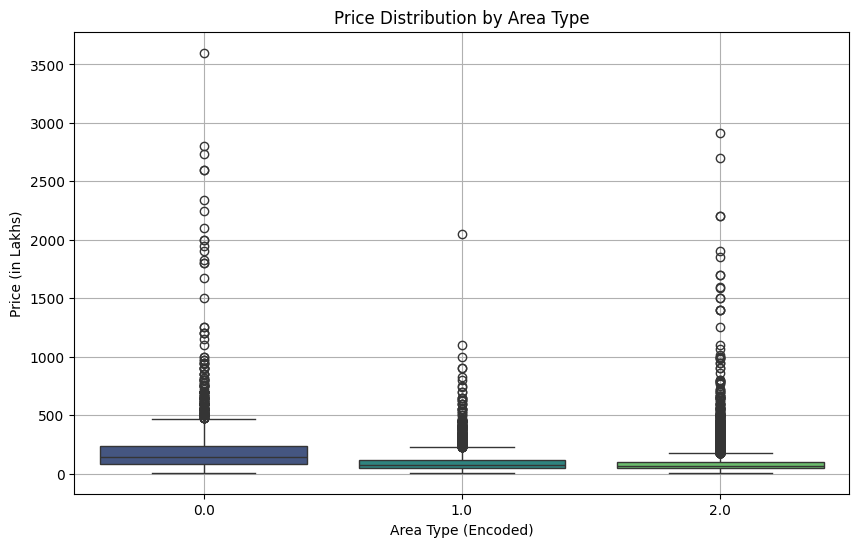

In [50]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='area_type_encoded', y='price', data=df, palette='viridis')
plt.title('Price Distribution by Area Type')
plt.xlabel('Area Type (Encoded)')
plt.ylabel('Price (in Lakhs)')
plt.grid(True)
plt.show()

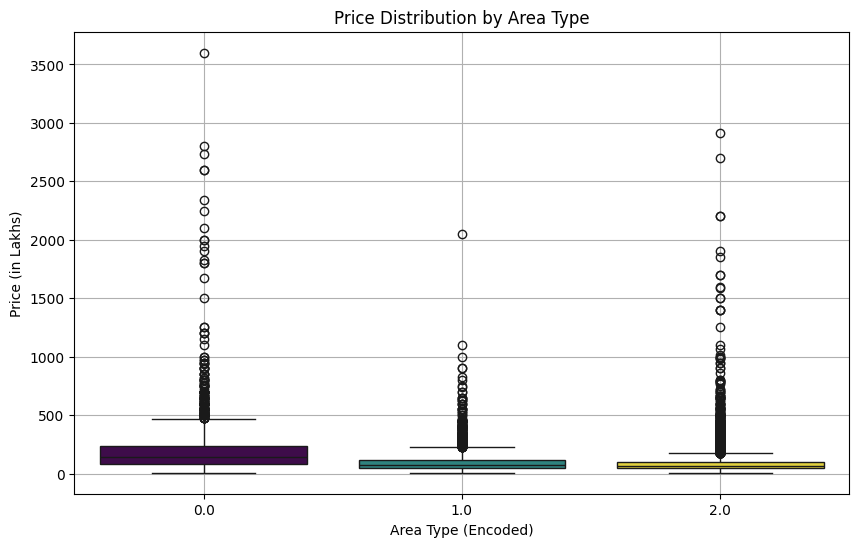

In [51]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='area_type_encoded', y='price', data=df, hue='area_type_encoded', palette='viridis', legend=False)
plt.title('Price Distribution by Area Type')
plt.xlabel('Area Type (Encoded)')
plt.ylabel('Price (in Lakhs)')
plt.grid(True)
plt.show()

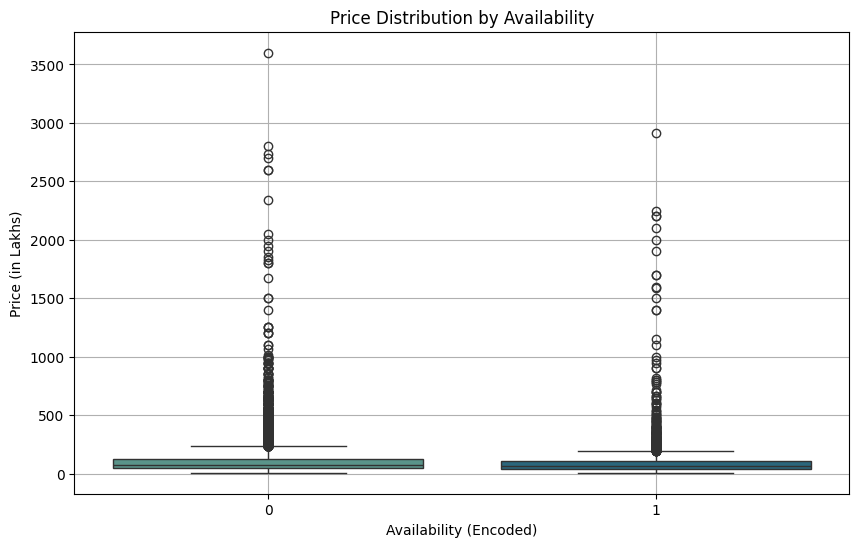

In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='availability_encoded', y='price', data=df, hue='availability_encoded', palette='crest', legend=False)
plt.title('Price Distribution by Availability')
plt.xlabel('Availability (Encoded)')
plt.ylabel('Price (in Lakhs)')
plt.grid(True)
plt.show()

# Building an Machine Learning Model

In [53]:
print("Missing values before handling:")
display(df[['location', 'total_sqft_numeric', 'area_type_encoded', 'availability_encoded', 'price']].isnull().sum())

Missing values before handling:


,0
location,1
total_sqft_numeric,46
area_type_encoded,87
availability_encoded,0
price,0


In [54]:
df.dropna(subset=['location'], inplace=True)

median_total_sqft = df['total_sqft_numeric'].median()
df['total_sqft_numeric'].fillna(median_total_sqft, inplace=True)

print("\nMissing values after handling:")
display(df[['location', 'total_sqft_numeric', 'area_type_encoded', 'availability_encoded', 'price']].isnull().sum())


Missing values after handling:


/tmp/ipython-input-2137974781.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_sqft_numeric'].fillna(median_total_sqft, inplace=True)


,0
location,0
total_sqft_numeric,0
area_type_encoded,87
availability_encoded,0
price,0


In [55]:
df.dropna(subset=['location'], inplace=True)

median_total_sqft = df['total_sqft_numeric'].median()
df['total_sqft_numeric'] = df['total_sqft_numeric'].fillna(median_total_sqft)

# Impute missing values in 'area_type_encoded' with its mode
mode_area_type_encoded = df['area_type_encoded'].mode()[0]
df['area_type_encoded'] = df['area_type_encoded'].fillna(mode_area_type_encoded)

print("\nMissing values after handling:")
display(df[['location', 'total_sqft_numeric', 'area_type_encoded', 'availability_encoded', 'price']].isnull().sum())


Missing values after handling:


,0
location,0
total_sqft_numeric,0
area_type_encoded,0
availability_encoded,0
price,0


In [56]:
from sklearn.preprocessing import OneHotEncoder

# Create an instance of OneHotEncoder with handle_unknown='ignore'
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit the encoder to the 'location' column and transform it
location_encoded = ohe.fit_transform(df[['location']])

# Get the feature names for the encoded columns
location_columns = ohe.get_feature_names_out(['location'])

# Create a new DataFrame from the dense array and the feature names
location_df = pd.DataFrame(location_encoded, columns=location_columns, index=df.index)

# Concatenate this new DataFrame with the original df, dropping the original 'location' column
df = pd.concat([df.drop('location', axis=1), location_df], axis=1)

print("DataFrame after one-hot encoding 'location' and dropping the original column:")
display(df.head())

DataFrame after one-hot encoding 'location' and dropping the original column:


,area_type,availability,size,society,total_sqft,bath,balcony,price,area_type_encoded,availability_encoded,...,location_rr nagar,location_sankeswari,location_sapthagiri Layout,location_sarjapura main road,location_singapura paradise,location_t.c palya,location_tc.palya,location_vinayakanagar,"location_white field,kadugodi",location_whitefiled
0,Super built-up Area,19-Dec,2,Coomee,1056,2.0,1.0,39.07,2.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Plot Area,Ready To Move,4,Theanmp,2600,5.0,3.0,120.00,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Built-up Area,Ready To Move,3,NaN,1440,2.0,3.0,62.00,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Super built-up Area,Ready To Move,3,Soiewre,1521,3.0,1.0,95.00,2.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Super built-up Area,Ready To Move,2,NaN,1200,2.0,1.0,51.00,2.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
feature_columns = [
    col for col in df.columns if col.startswith('location_')
] + ['total_sqft_numeric', 'area_type_encoded', 'availability_encoded']

X = df[feature_columns]
y = df['price']

print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

Shape of feature matrix X: (13319, 1308)
Shape of target vector y: (13319,)


In [58]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shapes of the training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shapes of the training and testing sets:
X_train shape: (10655, 1308)
X_test shape: (2664, 1308)
y_train shape: (10655,)
y_test shape: (2664,)


In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [60]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (R2): 0.4156
Mean Absolute Error (MAE): 43.68
Root Mean Squared Error (RMSE): 116.74
